# 🧠 Notebook 2 — VQ-VAE Training
**Runtime 1 — Run simultaneously with Notebook 3.**

Expected training time:
- T4  (16 GB): ~5–6 hrs | batch=2
- L4  (24 GB): ~3–4 hrs | batch=3  ← recommended
- A100 (40 GB): ~2 hrs  | batch=4  (expensive compute units)

Checkpoints save to Drive every 10 epochs — safe to run unattended.

In [2]:
import torch
print(f"""
PyTorch CUDA available: {torch.cuda.is_available()}""")
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU:  {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {vram:.1f} GB")
    if vram >= 35:
        print("✅ A100 — batch=4 (~2 hrs)")
    elif vram >= 20:
        print("✅ L4 — batch=3 (~3-4 hrs) ← sweet spot")
    else:
        print("✅ T4 — batch=2 (~5-6 hrs)")


PyTorch CUDA available: True
GPU:  NVIDIA L4
VRAM: 23.7 GB
✅ L4 — batch=3 (~3-4 hrs) ← sweet spot


In [3]:
# ── CELL 2: Setup ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys
REPO_DIR   = '/content/atml-brain-anomaly'
DRIVE_ROOT = '/content/drive/MyDrive/atml'

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/danielronak/atml-brain-anomaly.git {REPO_DIR}
else:
    !git -C {REPO_DIR} pull origin main

%cd {REPO_DIR}
sys.path.insert(0, REPO_DIR)

!pip install -q monai monai-generative einops nibabel tqdm pyyaml
print('✅ Setup complete.')

Mounted at /content/drive
Cloning into '/content/atml-brain-anomaly'...
remote: Enumerating objects: 296, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 296 (delta 68), reused 135 (delta 43), pack-reused 129 (from 1)
Receiving objects: 100% (296/296), 96.18 MiB | 36.06 MiB/s, done.
Resolving deltas: 100% (126/126), done.
/content/atml-brain-anomaly
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 kB 21.1 MB/s eta 0:00:00
✅ Setup complete.


In [4]:
# ── CELL 3: Load config + override Drive paths ─────────────────
import yaml, torch

with open("configs/default.yaml") as f:
    config = yaml.safe_load(f)

# ← UPDATE IF YOUR DRIVE PATHS DIFFER
config["data"]["ixi_dir"]        = f"{DRIVE_ROOT}/data/ixi"
config["data"]["brats_dir"]      = f"{DRIVE_ROOT}/data/brats2021"
config["data"]["checkpoint_dir"] = f"{DRIVE_ROOT}/checkpoints"
config["data"]["results_dir"]    = f"{DRIVE_ROOT}/results"
config["vqvae"]["epochs"] = 80          # was 100 — fits in one L4 session
config["vqvae"]["checkpoint_every"] = 5  # was 10 — lose less if it dies again

# Auto-detect GPU tier
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    if vram >= 35:
        config["data"]["batch_size"] = 4   # A100
    elif vram >= 20:
        config["data"]["batch_size"] = 3   # L4 (24 GB)
    else:
        config["data"]["batch_size"] = 2   # T4 (16 GB)

print(f"GPU VRAM:   {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Batch size: {config['data']['batch_size']}")
print(f"IXI dir:    {config['data']['ixi_dir']}")
print(f"Checkpoint: {config['data']['checkpoint_dir']}")
print(f"Epochs:     {config['vqvae']['epochs']}")


GPU VRAM:   23.7 GB
Batch size: 3
IXI dir:    /content/drive/MyDrive/atml/data/ixi
Checkpoint: /content/drive/MyDrive/atml/checkpoints
Epochs:     80


In [5]:
# ── CELL 4: Model smoke test (run BEFORE training) ─────────────
from src.models.vqvae import get_vqvae

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_vqvae(config).to(device)

dummy = torch.randn(1, 2, 128, 128, 128).to(device)
with torch.no_grad():
    recon, q_loss = model(dummy)

assert recon.shape == dummy.shape
print(f'✅ VQ-VAE forward pass OK')
print(f'   Input:  {dummy.shape}')
print(f'   Output: {recon.shape}')
print(f'   VRAM used: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB')

del dummy, recon
torch.cuda.empty_cache()

✅ VQ-VAE forward pass OK
   Input:  torch.Size([1, 2, 128, 128, 128])
   Output: torch.Size([1, 2, 128, 128, 128])
   VRAM used: 1.44 GB


In [6]:
# ── CELL 5: TRAIN ─────────────────────────────────────────────
# This cell runs for ~5-6 hours. Do NOT restart the runtime.
# Checkpoints save to Drive every 10 epochs — safe if session dies.

from src.training.train_vqvae import train

# Inject our config with Drive paths
import src.training.train_vqvae as vqvae_train
vqvae_train._CONFIG_OVERRIDE = config  # training script will use this if set

model, history = train(config_override=config)
print('\n🎉 VQ-VAE training complete!')

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


✅ GPU: NVIDIA L4
   VRAM: 23.7 GB

📂 Loading IXI dataloader...


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


[IXI] Found 577 paired T1+T2 subjects.
[IXI] Train: 519 | Val: 58


Loading dataset: 100%|██████████| 58/58 [02:16<00:00,  2.35s/it]


...

  Epoch  78/80 | Train Recon: 0.0181 | Quant: 0.0167 | Val Recon: 0.0200 | Time: 613s


Epoch 79/80: 100%|██████████| 173/173 [10:02<00:00,  3.48s/it, quant=0.0169, recon=0.0182]


  Epoch  79/80 | Train Recon: 0.0181 | Quant: 0.0167 | Val Recon: 0.0199 | Time: 614s


Epoch 80/80: 100%|██████████| 173/173 [10:02<00:00,  3.48s/it, quant=0.0145, recon=0.0153]


  Epoch  80/80 | Train Recon: 0.0181 | Quant: 0.0167 | Val Recon: 0.0202 | Time: 614s
  💾 Checkpoint saved: /content/drive/MyDrive/atml/checkpoints/vqvae/epoch_080.pth

✅ Training complete. Final model: /content/drive/MyDrive/atml/checkpoints/vqvae/final.pth
   Loss history: /content/drive/MyDrive/atml/results/vqvae_training_history.json

🎉 VQ-VAE training complete!


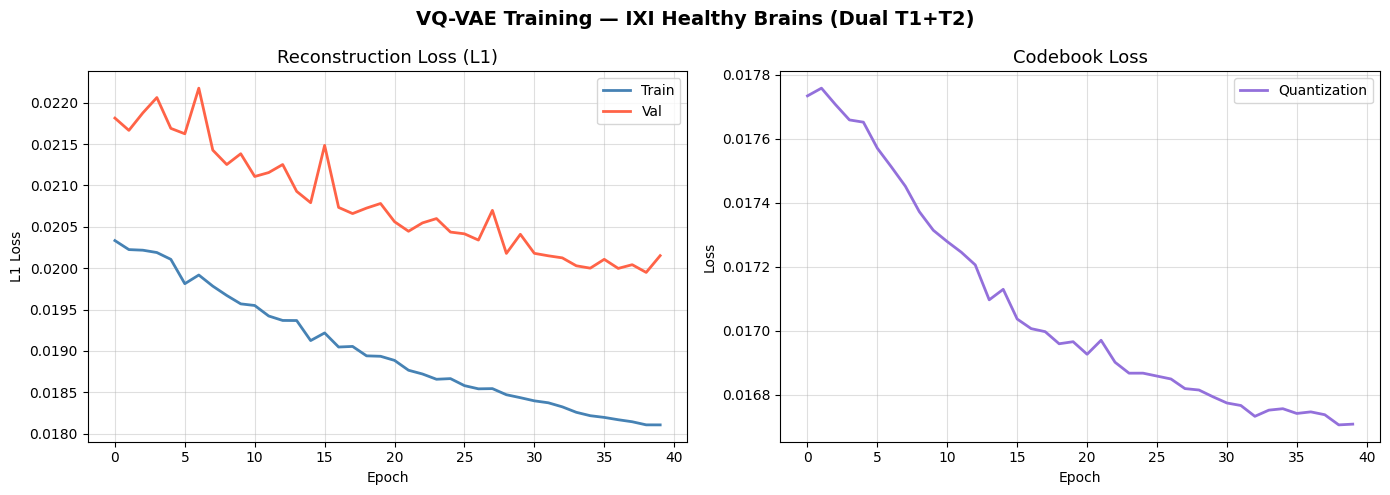

Saved: /content/drive/MyDrive/atml/results/vqvae_training_curves.png


In [7]:
# ── CELL 6: Plot training curves ──────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_recon'], label='Train', color='steelblue', linewidth=2)
axes[0].plot(history['val_recon'], label='Val', color='tomato', linewidth=2)
axes[0].set_title('Reconstruction Loss (L1)', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('L1 Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(history['train_quant'], label='Quantization', color='mediumpurple', linewidth=2)
axes[1].set_title('Codebook Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle('VQ-VAE Training — IXI Healthy Brains (Dual T1+T2)', fontsize=14, fontweight='bold')
plt.tight_layout()

from pathlib import Path
fig_path = f"{config['data']['results_dir']}/vqvae_training_curves.png"
Path(config['data']['results_dir']).mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


[IXI] Found 577 paired T1+T2 subjects.
[IXI] Train: 519 | Val: 58


Loading dataset: 100%|██████████| 58/58 [00:58<00:00,  1.01s/it]


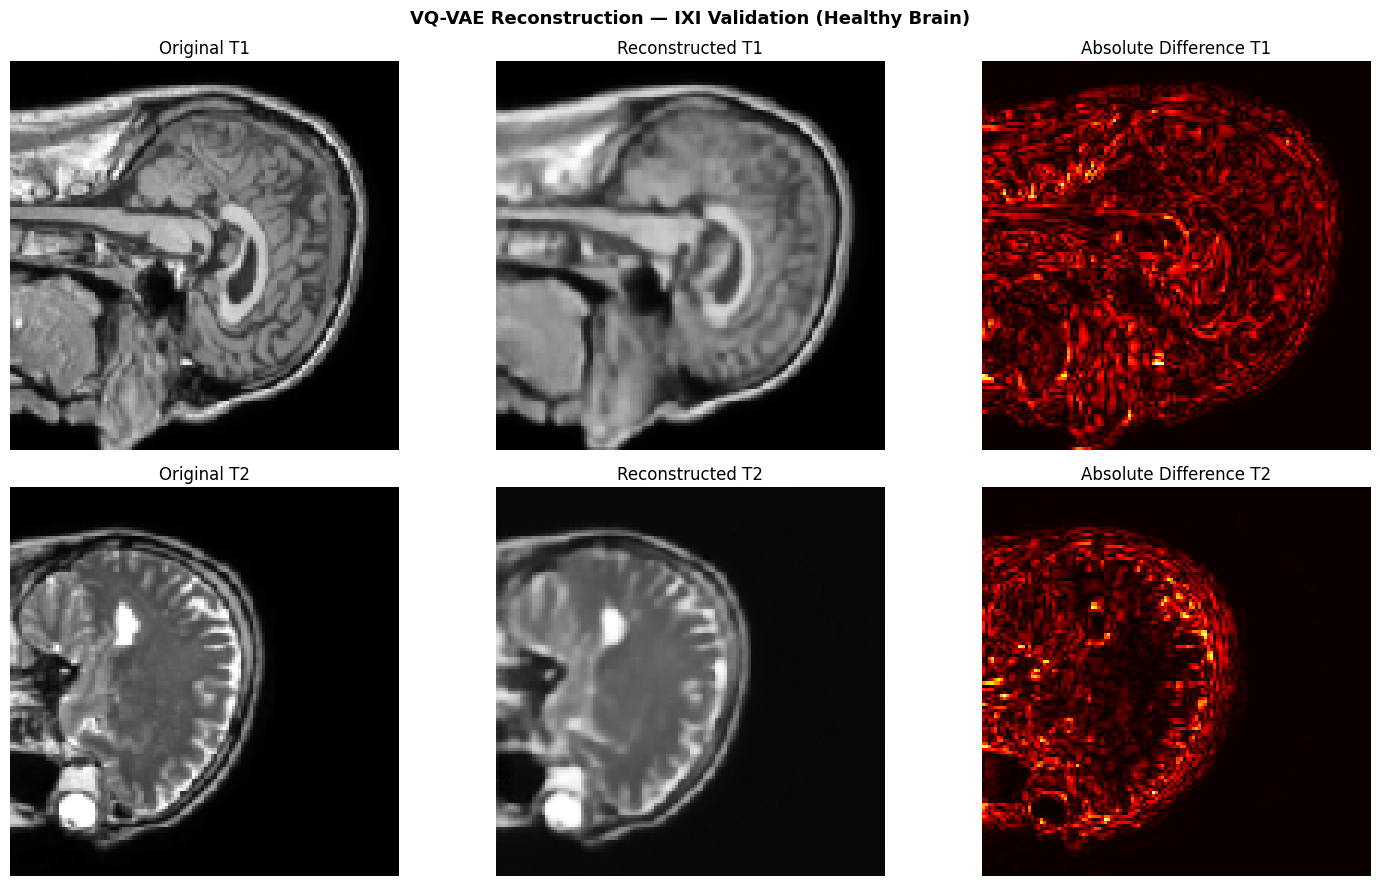

Saved: /content/drive/MyDrive/atml/results/vqvae_reconstruction_sample.png

✅ Notebook 2 complete! Proceed to Notebook 5 (evaluation) after Notebook 3 also finishes.


In [8]:
# ── CELL 7: Visualise reconstruction quality ───────────────────
from src.data.dataset import get_ixi_dataloaders

_, val_loader = get_ixi_dataloaders(config)
batch = next(iter(val_loader))
vol = batch['image'].to(device)

model.eval()
with torch.no_grad():
    recon, _ = model(vol)

vol_np   = vol[0].cpu().numpy()   # (2, D, H, W)
recon_np = recon[0].cpu().numpy()
s = vol_np.shape[1] // 2         # Middle slice

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for row, (chan, label) in enumerate([('0', 'T1'), ('1', 'T2')]):
    c = int(chan)
    orig_sl   = vol_np[c, s]
    recon_sl  = recon_np[c, s]
    diff_sl   = abs(orig_sl - recon_sl)

    axes[row, 0].imshow(orig_sl, cmap='gray')
    axes[row, 0].set_title(f'Original {label}')
    axes[row, 1].imshow(recon_sl, cmap='gray')
    axes[row, 1].set_title(f'Reconstructed {label}')
    axes[row, 2].imshow(diff_sl, cmap='hot')
    axes[row, 2].set_title(f'Absolute Difference {label}')
    for ax in axes[row]: ax.axis('off')

plt.suptitle('VQ-VAE Reconstruction — IXI Validation (Healthy Brain)', fontsize=13, fontweight='bold')
plt.tight_layout()
fig_path2 = f"{config['data']['results_dir']}/vqvae_reconstruction_sample.png"
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path2}')
print('\n✅ Notebook 2 complete! Proceed to Notebook 5 (evaluation) after Notebook 3 also finishes.')